In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster


In [2]:
df=pd.read_csv("../data/3_processed/paquet_phrases_lemm.csv")

In [3]:
df.head()

,nom_fichier,id_paquet,phrases_paquet,phrases_lemm
0,1893_20_Le_docteur_Pascal._clean.txt,0,Dans la chaleur de l’ardente après-midi de jui...,chaleur ardent après-midi juillet salle volet ...
1,1893_20_Le_docteur_Pascal._clean.txt,1,"Mais il dut prendre une chaise, la planche du ...",chaise planche haut haut grand taille planche ...
2,1893_20_Le_docteur_Pascal._clean.txt,2,"Oh! Monsieur, la religion n’a jamais fait de m...",monsieur religion mal idée sûr silence diverge...
3,1893_20_Le_docteur_Pascal._clean.txt,3,"De face, dans son visage séché, ses yeux garda...",face visage oeil flamme joli sourir grand-mère...
4,1893_20_Le_docteur_Pascal._clean.txt,4,s’écria la jeune fille. Mais elle était lancée...,jeune fille bon femme fond faubourg pile mort ...


In [4]:
vectorizer = TfidfVectorizer(
    min_df=3,
    max_df=0.8
)
X = vectorizer.fit_transform(df["phrases_lemm"])
X.shape

(5327, 11640)

In [5]:
scores = []

for k in range(2, 41):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X)
    score = silhouette_score(X, labels)
    scores.append((k, score))
    
scores

[(2, 0.004475928517467927),
 (3, 0.005085532226278628),
 (4, 0.005367943921983189),
 (5, 0.0053700317640884634),
 (6, 0.005528623534885547),
 (7, 0.0059323859842326555),
 (8, 0.006600169043749601),
 (9, 0.007065949867001049),
 (10, 0.006709403513351573),
 (11, 0.006953313440171792),
 (12, 0.007727379169701246),
 (13, 0.007439034425823989),
 (14, 0.007989922297319338),
 (15, 0.008551706971003721),
 (16, 0.00843446237529109),
 (17, 0.00863167854683103),
 (18, 0.0084399374209566),
 (19, 0.008567261947435088),
 (20, 0.008830191777532493),
 (21, 0.009752004342202367),
 (22, 0.009495197278672488),
 (23, 0.009313063127272316),
 (24, 0.010070431108315984),
 (25, 0.01007283767966752),
 (26, 0.009865173644778593),
 (27, 0.009574623488131886),
 (28, 0.010249014788885498),
 (29, 0.010298484491677506),
 (30, 0.010191382060872563),
 (31, 0.010088040397287848),
 (32, 0.010290234719376096),
 (33, 0.00976339944249227),
 (34, 0.009894526683324176),
 (35, 0.010206540500833479),
 (36, 0.009228478749461921

In [6]:
scores_df = pd.DataFrame(scores, columns=["k", "silhouette"])

scores_df.sort_values("silhouette", ascending=False).head(10)

,k,silhouette
35,37,0.010506
27,29,0.010298
38,40,0.010295
30,32,0.010290
26,28,0.010249
33,35,0.010207
28,30,0.010191
29,31,0.010088
23,25,0.010073
22,24,0.010070


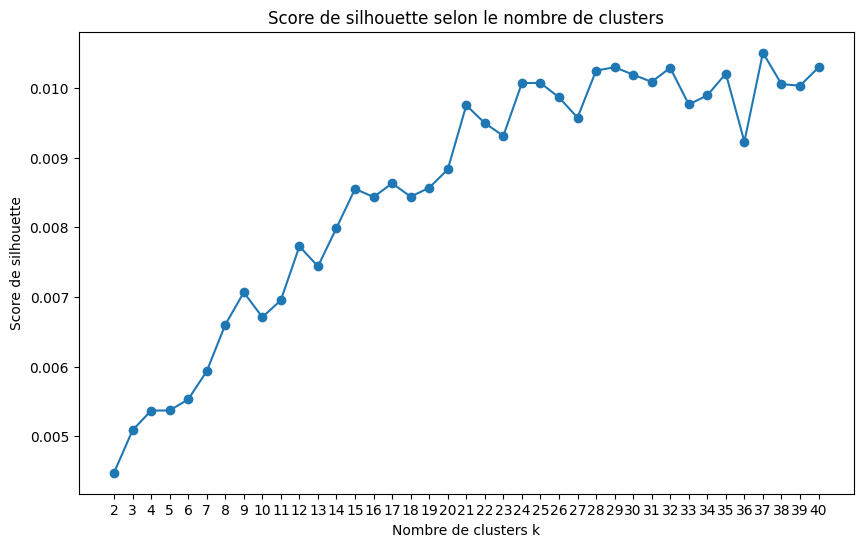

In [7]:
plt.figure(figsize=(10, 6))
plt.xticks(range(2, 41))

plt.plot(scores_df["k"], scores_df["silhouette"], marker="o")

plt.xlabel("Nombre de clusters k")

plt.ylabel("Score de silhouette")

plt.title("Score de silhouette selon le nombre de clusters")

plt.show()

In [8]:
kmeans= KMeans(n_clusters=29, 
               random_state=42,
               n_init=10)

df["cluster"] = kmeans.fit_predict(X) +1 

In [9]:
df.head()

,nom_fichier,id_paquet,phrases_paquet,phrases_lemm,cluster
0,1893_20_Le_docteur_Pascal._clean.txt,0,Dans la chaleur de l’ardente après-midi de jui...,chaleur ardent après-midi juillet salle volet ...,13
1,1893_20_Le_docteur_Pascal._clean.txt,1,"Mais il dut prendre une chaise, la planche du ...",chaise planche haut haut grand taille planche ...,13
2,1893_20_Le_docteur_Pascal._clean.txt,2,"Oh! Monsieur, la religion n’a jamais fait de m...",monsieur religion mal idée sûr silence diverge...,13
3,1893_20_Le_docteur_Pascal._clean.txt,3,"De face, dans son visage séché, ses yeux garda...",face visage oeil flamme joli sourir grand-mère...,15
4,1893_20_Le_docteur_Pascal._clean.txt,4,s’écria la jeune fille. Mais elle était lancée...,jeune fille bon femme fond faubourg pile mort ...,6


In [10]:
terms = vectorizer.get_feature_names_out()
centres = kmeans.cluster_centers_

for i, centre in enumerate(centres):
    top_indices = centre.argsort()[::-1][:10]
    mots = [terms[j] for j in top_indices]
    print(f"Cluster {i+1} :", " | ".join(mots))

Cluster 1 : verre | petit | table | maman | coup | femme | vin | eau | tête | homme
Cluster 2 : instituteur | école | enfant | vérité | élève | petit | église | père | classe | bon
Cluster 3 : salon | dame | femme | monsieur | petit | blanc | satin | homme | jeune | rose
Cluster 4 : chambre | porte | lit | monsieur | heure | femme | petit | maison | escalier | fenêtre
Cluster 5 : enfant | femme | nourrice | petit | usine | constance | fille | mari | monsieur | cher
Cluster 6 : mère | fille | petit | enfant | père | femme | fils | bon | jeune | oeil
Cluster 7 : train | gare | chef | machine | voie | heure | express | mécanicien | tunnel | voyageur
Cluster 8 : amour | cœur | vie | jeune | enfant | femme | fille | jour | homme | tendresse
Cluster 9 : comte | comtesse | monsieur | scène | loge | femme | prullière | homme | théâtre | dame
Cluster 10 : abbé | prêtre | curé | monsieur | église | bon | tête | petit | frère | enfant
Cluster 11 : arbre | soleil | herbe | ciel | eau | ombre | jar

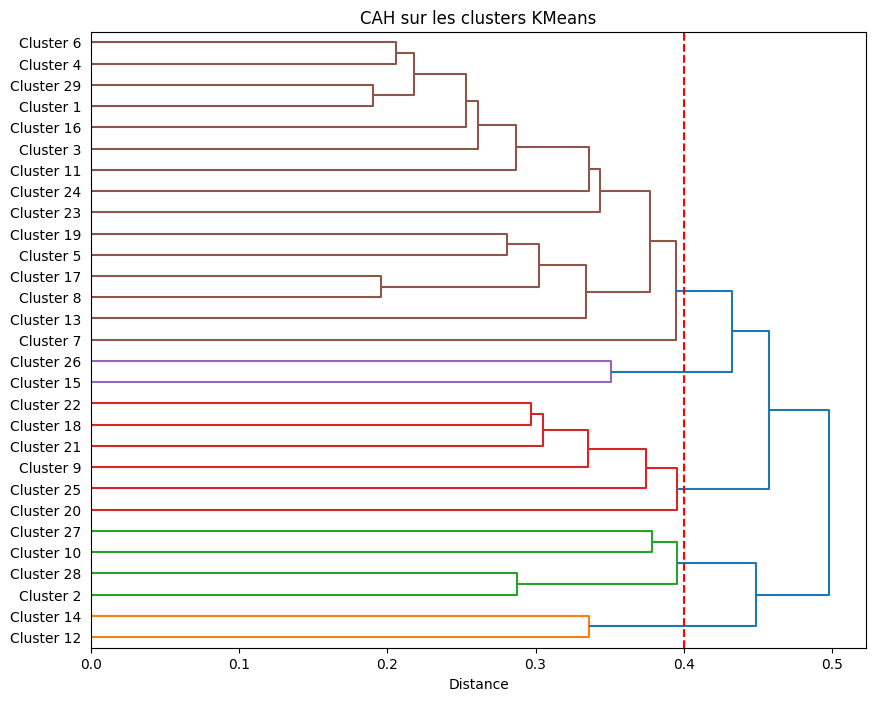

In [11]:
plt.figure(figsize=(10, 8))
Z = linkage(centres, method='ward')

dendrogram(
    Z,
    labels=[f"Cluster {i+1}" for i in range(kmeans.n_clusters)],
    orientation="right",
    color_threshold=0.40
)

plt.axvline(x=0.40, color="red", linestyle="--")

plt.title("CAH sur les clusters KMeans")
plt.xlabel("Distance")
plt.show()

In [12]:
noms_clusters_kmeans = {
    1: "La table, les repas et les boissons",
    2: "L’école, les élèves et l’instruction",
    3: "Le salon, l’aristocratie et les apparences",
    4: "La chambre, le lit et l’espace domestique",
    5: "L’enfance, la maternité et la pauvreté",
    6: "La mère, les enfants et la famille",
    7: "Le monde ferroviaire",
    8: "L’amour, les sentiments et la jeunesse",
    9: "Le théâtre, la loge et les scènes mondaines",
    10: "Le clergé et la paroisse",
    11: "La nature et le paysage",
    12: "Le miracle, le pèlerinage et la religion",
    13: "Le monde médical et la santé",
    14: "Le pèlerinage, la maladie et le voyage",
    15: "L’insurrection et la révolution",
    16: "Le quartier, la rue et la ville",
    17: "Le désir, le corps et les relations amoureuses",
    18: "Le pouvoir politique et les affaires publiques",
    19: "Le travail, le peuple et le monde ouvrier",
    20: "La bourse, la finance et les affaires",
    21: "L’argent du quotidien",
    22: "Les conversations et les scènes domestiques",
    23: "Le monde artistique et la peinture",
    24: "La mine, les ouvriers et la grève",
    25: "Le magasin, la vente et les clientes",
    26: "La guerre, les soldats et l’armée",
    27: "Le pouvoir religieux",
    28: "Les liens familiaux, l’écriture et la justice",
    29: "La terre, les animaux et le monde paysan"
}

In [13]:
df["nom_cluster"] = df["cluster"].map(noms_clusters_kmeans)

In [14]:
df[["cluster", "nom_cluster", "phrases_paquet"]].head()

,cluster,nom_cluster,phrases_paquet
0,13,Le monde médical et la santé,Dans la chaleur de l’ardente après-midi de jui...
1,13,Le monde médical et la santé,"Mais il dut prendre une chaise, la planche du ..."
2,13,Le monde médical et la santé,"Oh! Monsieur, la religion n’a jamais fait de m..."
3,15,L’insurrection et la révolution,"De face, dans son visage séché, ses yeux garda..."
4,6,"La mère, les enfants et la famille",s’écria la jeune fille. Mais elle était lancée...


In [15]:
for i, centre in enumerate(centres, start=1):
    top_indices = centre.argsort()[::-1][:10]
    mots = [terms[j] for j in top_indices]
    print(f"Cluster {i}/ {noms_clusters_kmeans[i]} :", " | ".join(mots))

Cluster 1/ La table, les repas et les boissons : verre | petit | table | maman | coup | femme | vin | eau | tête | homme
Cluster 2/ L’école, les élèves et l’instruction : instituteur | école | enfant | vérité | élève | petit | église | père | classe | bon
Cluster 3/ Le salon, l’aristocratie et les apparences : salon | dame | femme | monsieur | petit | blanc | satin | homme | jeune | rose
Cluster 4/ La chambre, le lit et l’espace domestique : chambre | porte | lit | monsieur | heure | femme | petit | maison | escalier | fenêtre
Cluster 5/ L’enfance, la maternité et la pauvreté : enfant | femme | nourrice | petit | usine | constance | fille | mari | monsieur | cher
Cluster 6/ La mère, les enfants et la famille : mère | fille | petit | enfant | père | femme | fils | bon | jeune | oeil
Cluster 7/ Le monde ferroviaire : train | gare | chef | machine | voie | heure | express | mécanicien | tunnel | voyageur
Cluster 8/ L’amour, les sentiments et la jeunesse : amour | cœur | vie | jeune | enfa

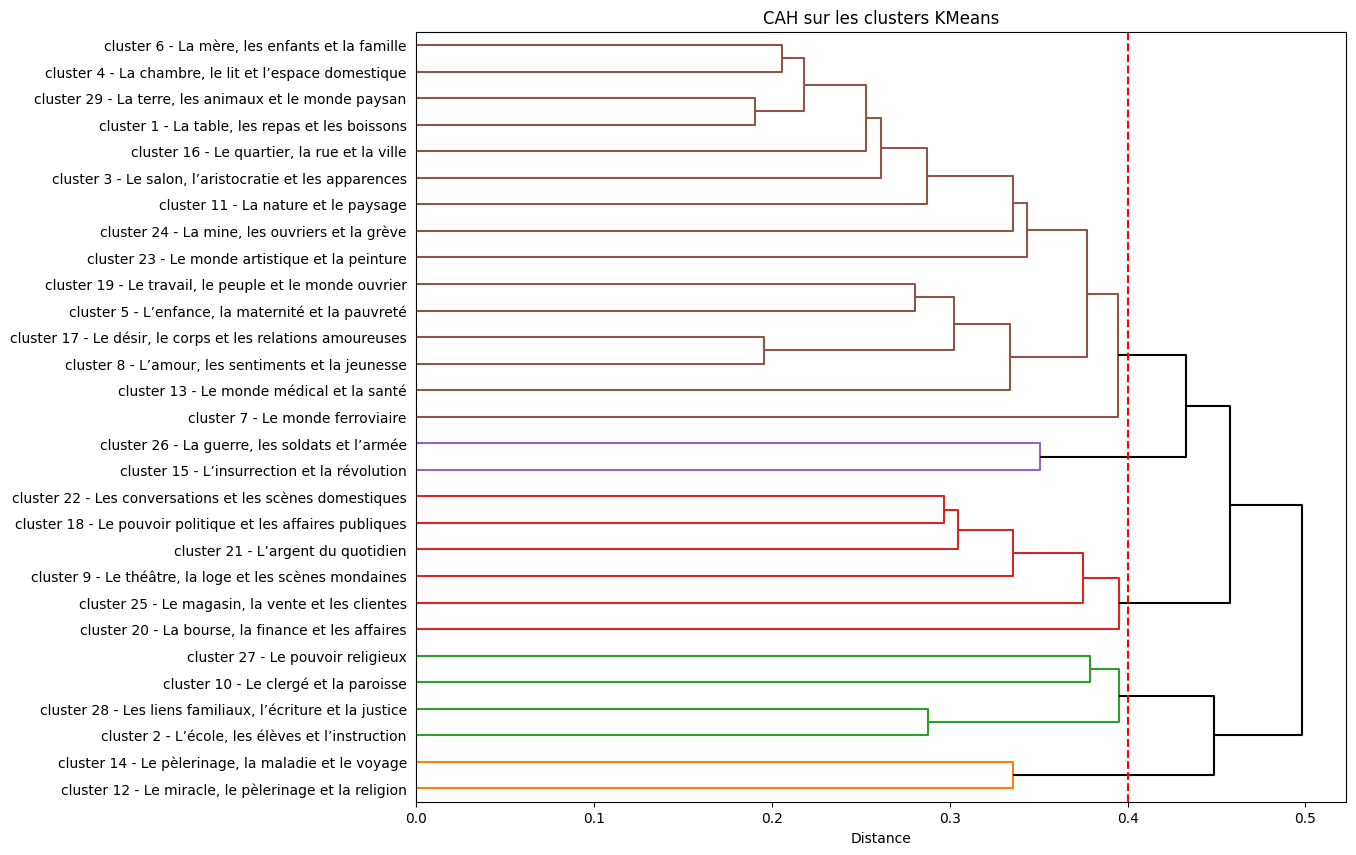

In [16]:
labels_clusters = [
    f"cluster {i} - {noms_clusters_kmeans[i]}" 
    for i in range(1, kmeans.n_clusters + 1)
]

plt.figure(figsize=(12, 10))
Z = linkage(centres, method='ward')

dendrogram(
    Z,
    labels=labels_clusters,
    orientation="right",
    color_threshold=0.40,
    above_threshold_color="black"
)

plt.axvline(x=0.40, color="red", linestyle="--")

plt.title("CAH sur les clusters KMeans")
plt.xlabel("Distance")
plt.show()

In [17]:
groupes_cah = fcluster(Z, t=0.40, criterion="distance")

df_groupes = pd.DataFrame({
    "cluster": range(1, kmeans.n_clusters + 1),
    "groupe_cah": groupes_cah
})

df_groupes["nom_cluster"] = df_groupes["cluster"].map(noms_clusters_kmeans)

df_groupes.sort_values("groupe_cah")

,cluster,groupe_cah,nom_cluster
13,14,1,"Le pèlerinage, la maladie et le voyage"
11,12,1,"Le miracle, le pèlerinage et la religion"
1,2,2,"L’école, les élèves et l’instruction"
26,27,2,Le pouvoir religieux
27,28,2,"Les liens familiaux, l’écriture et la justice"
9,10,2,Le clergé et la paroisse
8,9,3,"Le théâtre, la loge et les scènes mondaines"
19,20,3,"La bourse, la finance et les affaires"
20,21,3,L’argent du quotidien
17,18,3,Le pouvoir politique et les affaires publiques


In [18]:
for groupe, data in df_groupes.groupby("groupe_cah"):
    print(f"\nGroupe {groupe}")
    for _, row in data.iterrows():
        print(f"- Cluster {row['cluster']} : {row['nom_cluster']}")


Groupe 1
- Cluster 12 : Le miracle, le pèlerinage et la religion
- Cluster 14 : Le pèlerinage, la maladie et le voyage

Groupe 2
- Cluster 2 : L’école, les élèves et l’instruction
- Cluster 10 : Le clergé et la paroisse
- Cluster 27 : Le pouvoir religieux
- Cluster 28 : Les liens familiaux, l’écriture et la justice

Groupe 3
- Cluster 9 : Le théâtre, la loge et les scènes mondaines
- Cluster 18 : Le pouvoir politique et les affaires publiques
- Cluster 20 : La bourse, la finance et les affaires
- Cluster 21 : L’argent du quotidien
- Cluster 22 : Les conversations et les scènes domestiques
- Cluster 25 : Le magasin, la vente et les clientes

Groupe 4
- Cluster 15 : L’insurrection et la révolution
- Cluster 26 : La guerre, les soldats et l’armée

Groupe 5
- Cluster 1 : La table, les repas et les boissons
- Cluster 3 : Le salon, l’aristocratie et les apparences
- Cluster 4 : La chambre, le lit et l’espace domestique
- Cluster 5 : L’enfance, la maternité et la pauvreté
- Cluster 6 : La mè

In [19]:
noms_groupes_cah = {
    1: "Religion locale et autorité cléricale",
    2: "Guerre, insurrection et conflit politique",
    3: "Institutions, croyances et encadrement social",
    4: "Argent, dettes et circulation financière",
    5: "Vie quotidienne, espaces sociaux et expériences individuelles"
}


In [20]:
df_groupes["nom_groupe_cah"] = df_groupes["groupe_cah"].map(noms_groupes_cah)

In [21]:
cluster_vers_groupe = dict(zip(df_groupes["cluster"], df_groupes["groupe_cah"]))

df["groupe_cah"] = df["cluster"].map(cluster_vers_groupe)
df["nom_groupe_cah"] = df["groupe_cah"].map(noms_groupes_cah)

In [22]:
df.head()

,nom_fichier,id_paquet,phrases_paquet,phrases_lemm,cluster,nom_cluster,groupe_cah,nom_groupe_cah
0,1893_20_Le_docteur_Pascal._clean.txt,0,Dans la chaleur de l’ardente après-midi de jui...,chaleur ardent après-midi juillet salle volet ...,13,Le monde médical et la santé,5,"Vie quotidienne, espaces sociaux et expérience..."
1,1893_20_Le_docteur_Pascal._clean.txt,1,"Mais il dut prendre une chaise, la planche du ...",chaise planche haut haut grand taille planche ...,13,Le monde médical et la santé,5,"Vie quotidienne, espaces sociaux et expérience..."
2,1893_20_Le_docteur_Pascal._clean.txt,2,"Oh! Monsieur, la religion n’a jamais fait de m...",monsieur religion mal idée sûr silence diverge...,13,Le monde médical et la santé,5,"Vie quotidienne, espaces sociaux et expérience..."
3,1893_20_Le_docteur_Pascal._clean.txt,3,"De face, dans son visage séché, ses yeux garda...",face visage oeil flamme joli sourir grand-mère...,15,L’insurrection et la révolution,4,"Argent, dettes et circulation financière"
4,1893_20_Le_docteur_Pascal._clean.txt,4,s’écria la jeune fille. Mais elle était lancée...,jeune fille bon femme fond faubourg pile mort ...,6,"La mère, les enfants et la famille",5,"Vie quotidienne, espaces sociaux et expérience..."


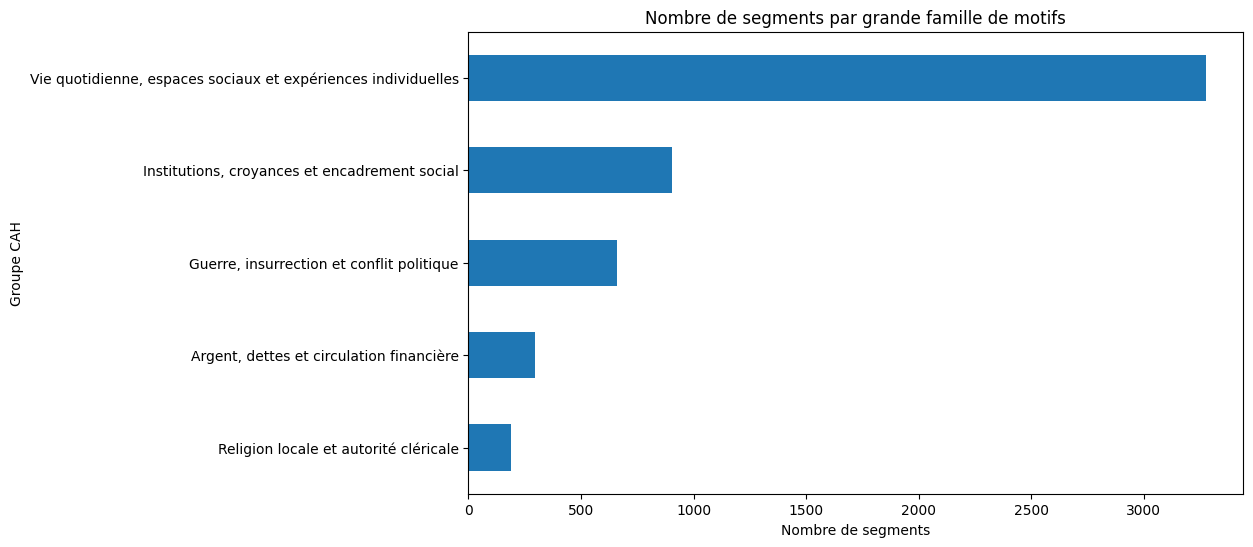

In [23]:
counts = df["nom_groupe_cah"].value_counts().sort_values()

plt.figure(figsize=(10, 6))
counts.plot(kind="barh")

plt.title("Nombre de segments par grande famille de motifs")
plt.xlabel("Nombre de segments")
plt.ylabel("Groupe CAH")
plt.show()

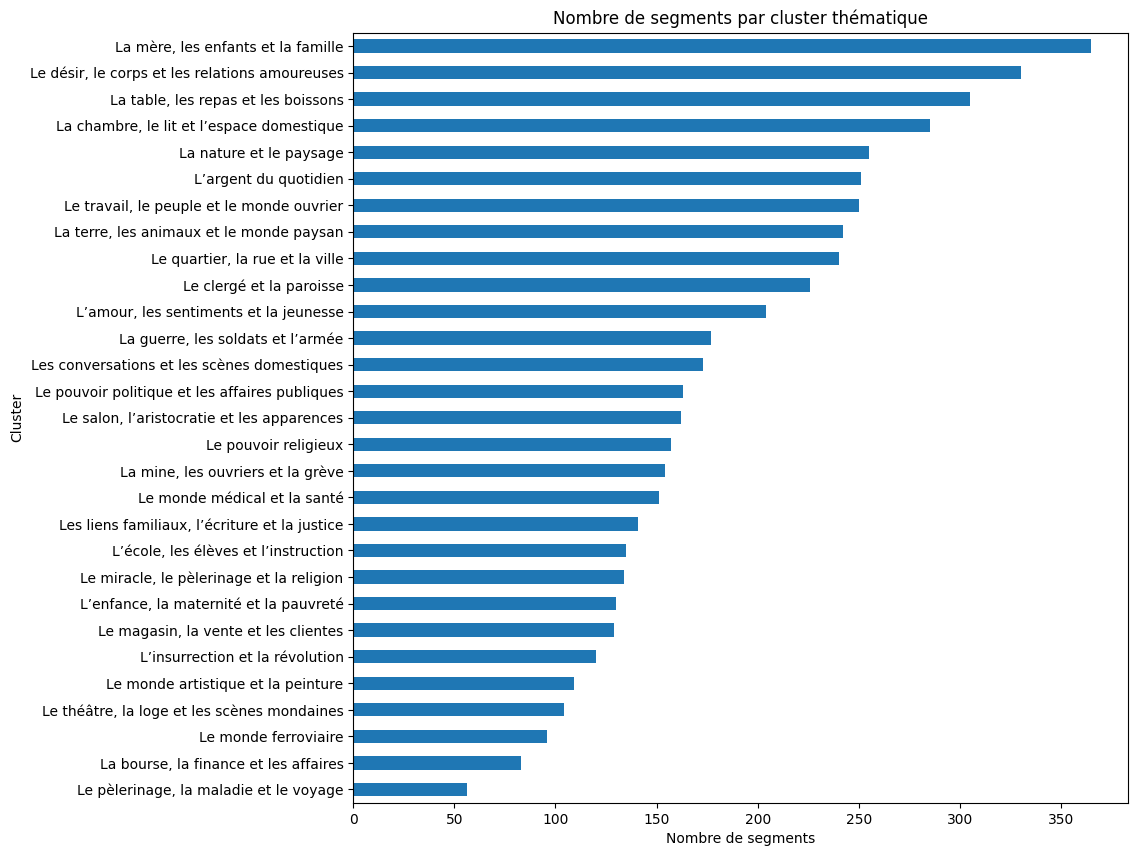

In [24]:
counts = df["nom_cluster"].value_counts().sort_values()

plt.figure(figsize=(10, 10))
counts.plot(kind="barh")

plt.title("Nombre de segments par cluster thématique")
plt.xlabel("Nombre de segments")
plt.ylabel("Cluster")
plt.show()

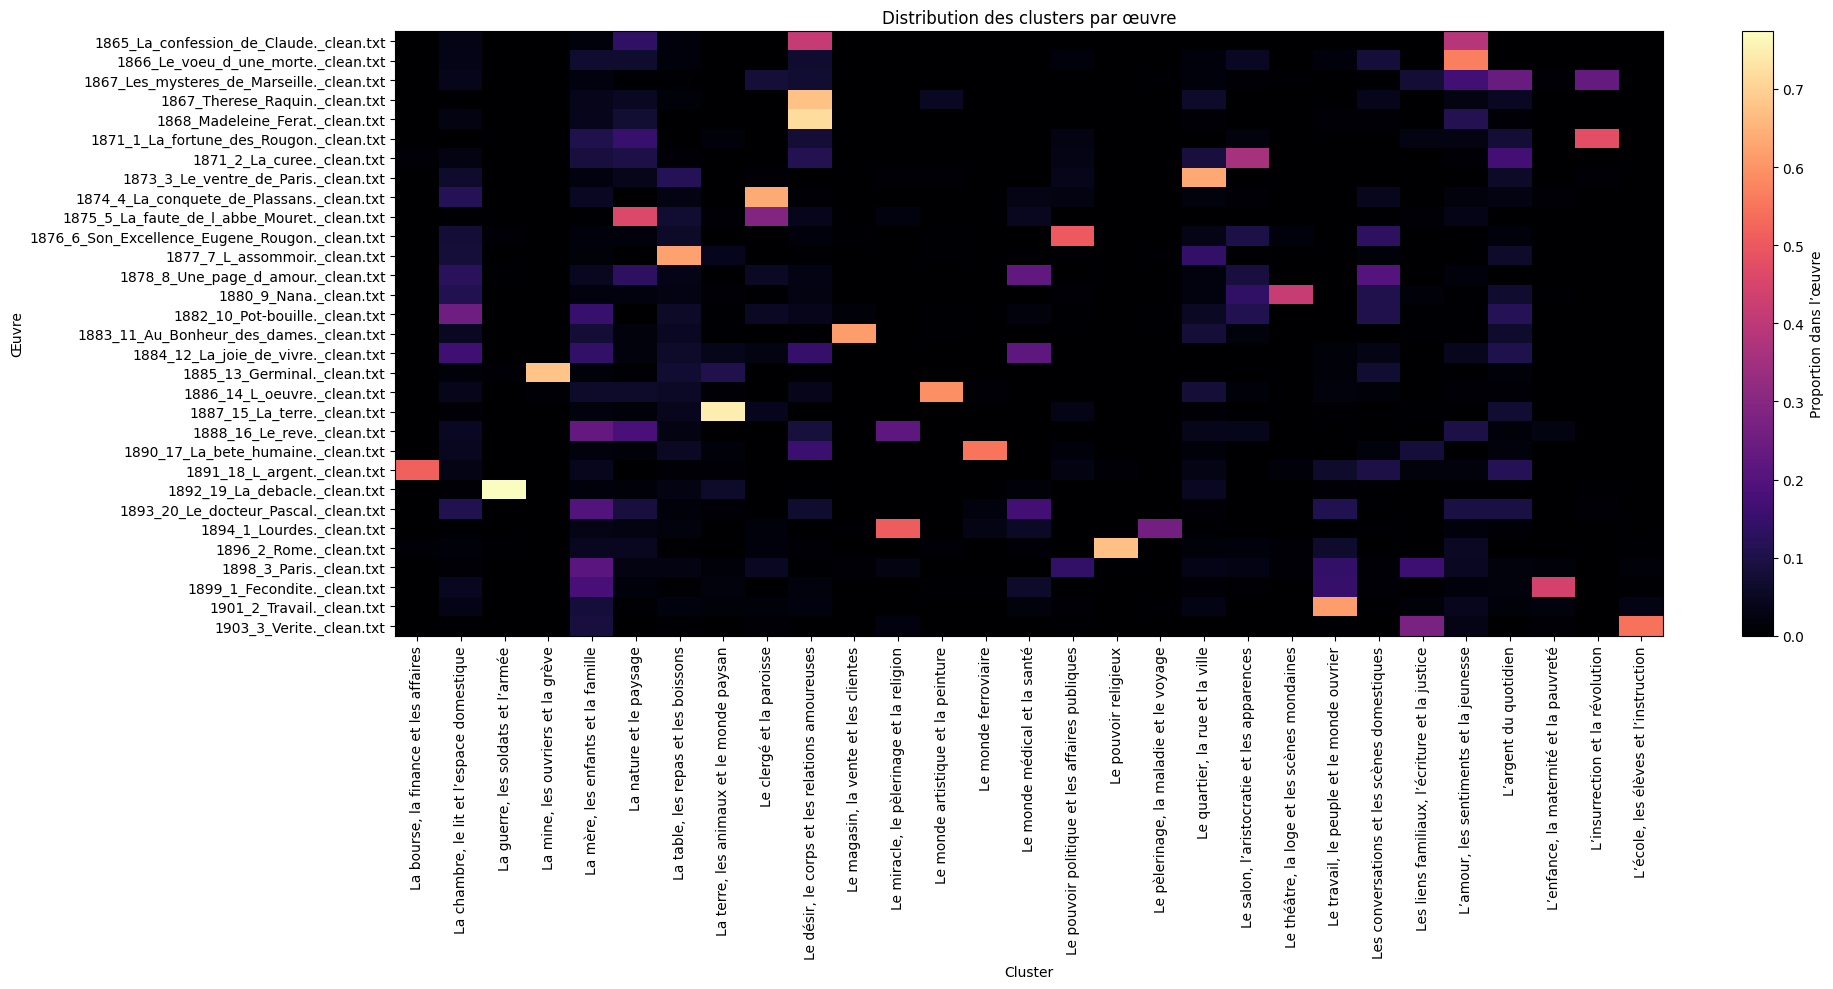

In [25]:
table = pd.crosstab(
    df["nom_fichier"],
    df["nom_cluster"],
    normalize="index"
)

plt.figure(figsize=(20, 10))
plt.imshow(table, aspect="auto", cmap="magma")

plt.xticks(range(len(table.columns)), table.columns, rotation=90)
plt.yticks(range(len(table.index)), table.index)

plt.title("Distribution des clusters par œuvre")
plt.xlabel("Cluster")
plt.ylabel("Œuvre")
plt.colorbar(label="Proportion dans l’œuvre")
plt.tight_layout()
plt.show()

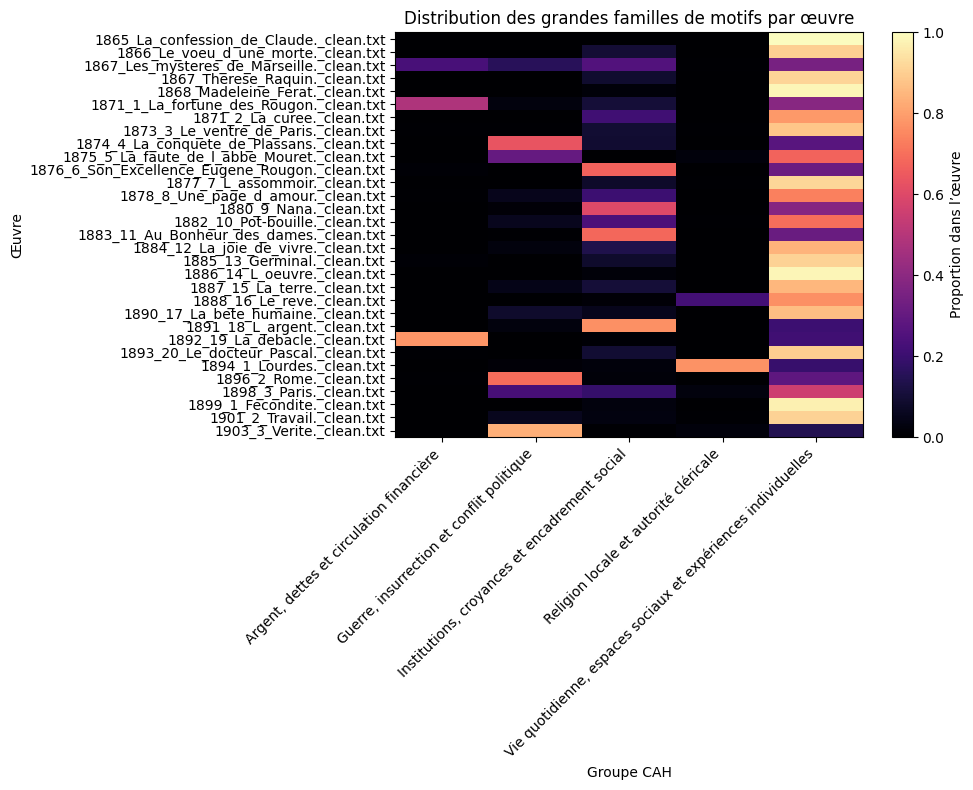

In [28]:
table_groupes = pd.crosstab(
    df["nom_fichier"],
    df["nom_groupe_cah"],
    normalize="index"
)

plt.figure(figsize=(10, 8))
plt.imshow(table_groupes, aspect="auto", cmap="magma")

plt.xticks(range(len(table_groupes.columns)), table_groupes.columns, rotation=45, ha="right")
plt.yticks(range(len(table_groupes.index)), table_groupes.index)

plt.title("Distribution des grandes familles de motifs par œuvre")
plt.xlabel("Groupe CAH")
plt.ylabel("Œuvre")
plt.colorbar(label="Proportion dans l’œuvre")
plt.tight_layout()
plt.show()